## Homework 3: Supervised Learning

### Exercise 1: Logistic Regression on a Toy 2D Dataset

In [16]:
import numpy as np
import matplotlib.pyplot as plt

In [17]:
np.random.seed(0)

N0, N1 = 200, 200

mu0 = np.array([-2.0, -2.0])
mu1 = np.array([ 2.0,  2.0])

cov0 = 1.0 * np.eye(2)
cov1 = 0.5 * np.eye(2)

X0 = np.random.multivariate_normal(mu0, cov0, size=N0)
X1 = np.random.multivariate_normal(mu1, cov1, size=N1)

y0 = np.zeros((N0, 1))
y1 = np.ones((N1, 1))

X = np.vstack([X0, X1])
y = np.vstack([y0, y1])

X_aug = np.hstack([np.ones((len(X), 1)), X])

In [18]:
def sigmoid(z):
    z = np.clip(z, -50, 50)
    return 1.0 / (1.0 + np.exp(-z))

def l(theta, X, y):
    """
    Binary cross-entropy loss (mean)
    theta: (d,1)
    X: (N,d)
    y: (N,1)
    """
    p = sigmoid(X @ theta)
    eps = 1e-12
    p = np.clip(p, eps, 1 - eps)
    return -(y * np.log(p) + (1 - y) * np.log(1 - p)).mean()

def grad_l(theta, X, y):
    """
    Gradient of mean BCE for logistic regression
    """
    return (X.T @ (sigmoid(X @ theta) - y)) / len(y)

def accuracy(theta, X, y):
    preds = (sigmoid(X @ theta) >= 0.5).astype(int)
    return (preds == y).mean()

In [19]:
def gradient_descent(l, grad_l, X, y, lr=1e-2, epochs=2000, tol_grad=1e-6):
    N, d = X.shape
    theta = np.zeros((d, 1))
    losses, accs = [], []

    for epoch in range(epochs):
        g = grad_l(theta, X, y)
        gnorm = np.linalg.norm(g)

        losses.append(l(theta, X, y))
        accs.append(accuracy(theta, X, y))

        if gnorm < tol_grad:
            break

        theta -= lr * g

    return theta, np.array(losses), np.array(accs)

In [ ]:
def plot_dataset_and_boundary(theta, X_raw, y, title="Logistic Regression decision boundary"):
    y_flat = y.reshape(-1)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_raw[y_flat == 0, 0], X_raw[y_flat == 0, 1], s=20, label="Class 0")
    plt.scatter(X_raw[y_flat == 1, 0], X_raw[y_flat == 1, 1], s=20, label="Class 1")

    x1_min, x1_max = X_raw[:, 0].min() - 1, X_raw[:, 0].max() + 1
    xs = np.linspace(x1_min, x1_max, 200)

    theta = theta.reshape(-1)
    t0, t1, t2 = theta[0], theta[1], theta[2]

    if abs(t2) < 1e-12:
        # vertical line: theta0 + theta1*x1 = 0 -> x1 = -theta0/theta1
        if abs(t1) > 1e-12:
            x_vert = -t0 / t1
            plt.axvline(x_vert, linewidth=2, label=r"$\theta^T\tilde{x}=0$")
    else:
        ys = -(t0 + t1 * xs) / t2
        plt.plot(xs, ys, linewidth=2, label=r"$\theta^T\tilde{x}=0$")

    plt.title(title)
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    
def plot_training_curves(losses, accs, title_prefix="Training"):
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title_prefix)

    axs[0].plot(losses)
    axs[0].set_title("Loss vs epoch")
    axs[0].set_xlabel("Epoch")
    axs[0].set_ylabel("Loss")
    axs[0].grid(alpha=0.3)

    axs[1].plot(accs)
    axs[1].set_title("Accuracy vs epoch")
    axs[1].set_xlabel("Epoch")
    axs[1].set_ylabel("Accuracy")
    axs[1].grid(alpha=0.3)

    plt.show()

GD final loss: 0.009292
GD final accuracy: 100.00%
theta = [-0.1237174   1.6836068   1.69257444]


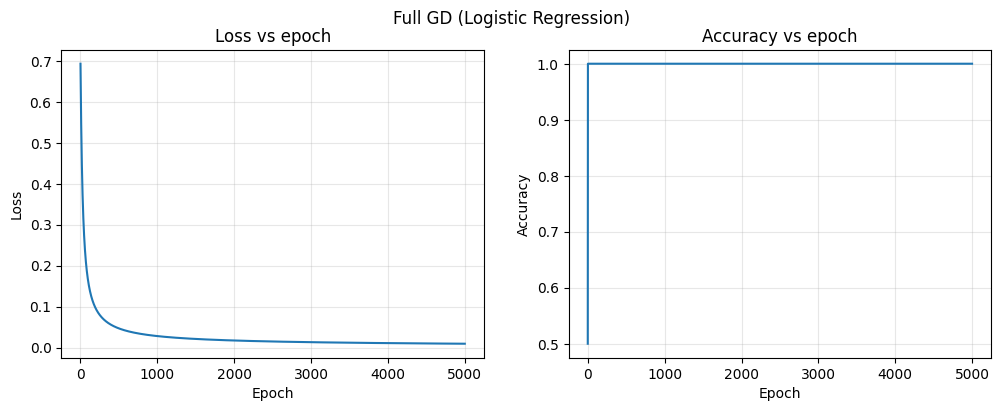

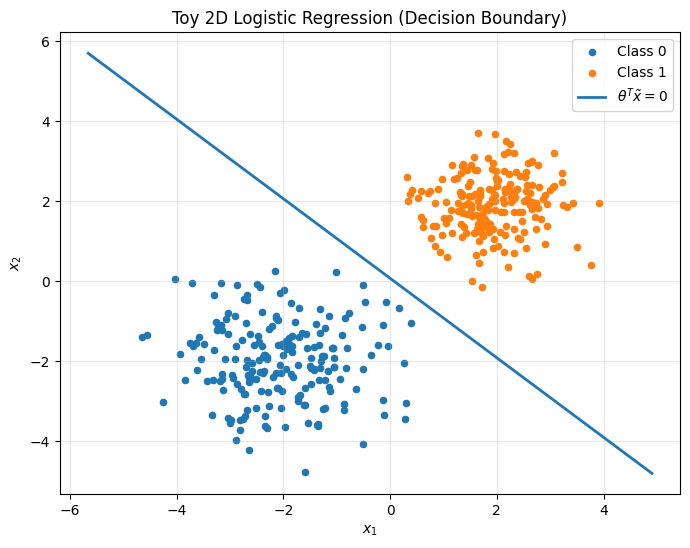

In [21]:
theta_gd, losses_gd, accs_gd = gradient_descent(
    l, grad_l, X_aug, y,
    lr=1e-2, epochs=5000, tol_grad=1e-6
)

print(f"GD final loss: {losses_gd[-1]:.6f}")
print(f"GD final accuracy: {accs_gd[-1]*100:.2f}%")
print("theta =", theta_gd.ravel())

plot_training_curves(losses_gd, accs_gd, title_prefix="Full GD (Logistic Regression)")
plot_dataset_and_boundary(theta_gd, X, y, title="Toy 2D Logistic Regression (Decision Boundary)")